In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


### Part 1

#### Visualization

In [29]:
directory = 'Training'
dirs = [d for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]

In [30]:
print(dirs)

['Austen', 'Baum', 'Verne']


In [ ]:
corpus = []
authors = []

for directory in dirs:
    author = os.listdir(f"Training/{directory}")
    for book in author:
        all_words = ''
        # Read files
        with open(f"Training/{directory}/{book}", 'r', encoding='utf-8') as f:
            # Reads the entire file as one big string
            all_words = f.read()
        corpus.append(all_words)
        authors.append(directory)

vectorizer = TfidfVectorizer(stop_words='english')
tfidf = vectorizer.fit_transform(corpus)

pca_results = PCA(n_components=2).fit_transform(tfidf.toarray())

In [45]:
print(authors)
print(pca_results)

['Austen', 'Austen', 'Austen', 'Austen', 'Baum', 'Baum', 'Baum', 'Baum', 'Verne', 'Verne', 'Verne', 'Verne']
[[-0.28073346 -0.33018991]
 [-0.27105073 -0.33316677]
 [-0.30439932 -0.33873216]
 [-0.30975137 -0.39868176]
 [ 0.4498929   0.02531968]
 [ 0.60053749  0.01228354]
 [ 0.59846538 -0.00267145]
 [ 0.55761382  0.00430825]
 [-0.3282717   0.61362776]
 [-0.24605514 -0.01924699]
 [-0.33226097  0.65406999]
 [-0.1339869   0.11307983]]


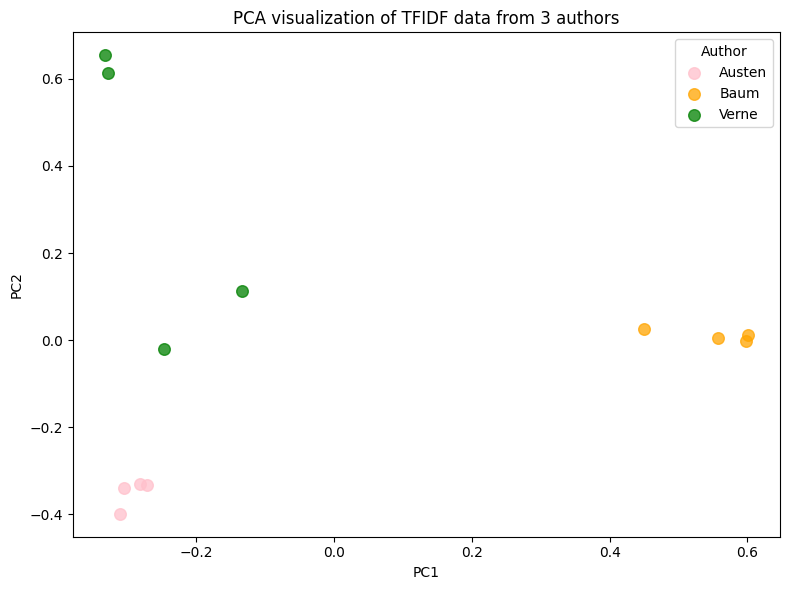

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))

unique_authors = sorted(set(authors))
colors = {'Austen': 'pink',
          'Baum': 'orange',
          'Verne': 'green'}

for author in unique_authors:
    mask = [l == author for l in authors]
    pts = pca_results[mask]
    ax.scatter(pts[:, 0], pts[:, 1], label=author, color=colors[author], alpha=0.75, s=70)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Author')
plt.title("PCA visualization of TFIDF data from 3 authors")
plt.tight_layout()
plt.show()

#### Prediction